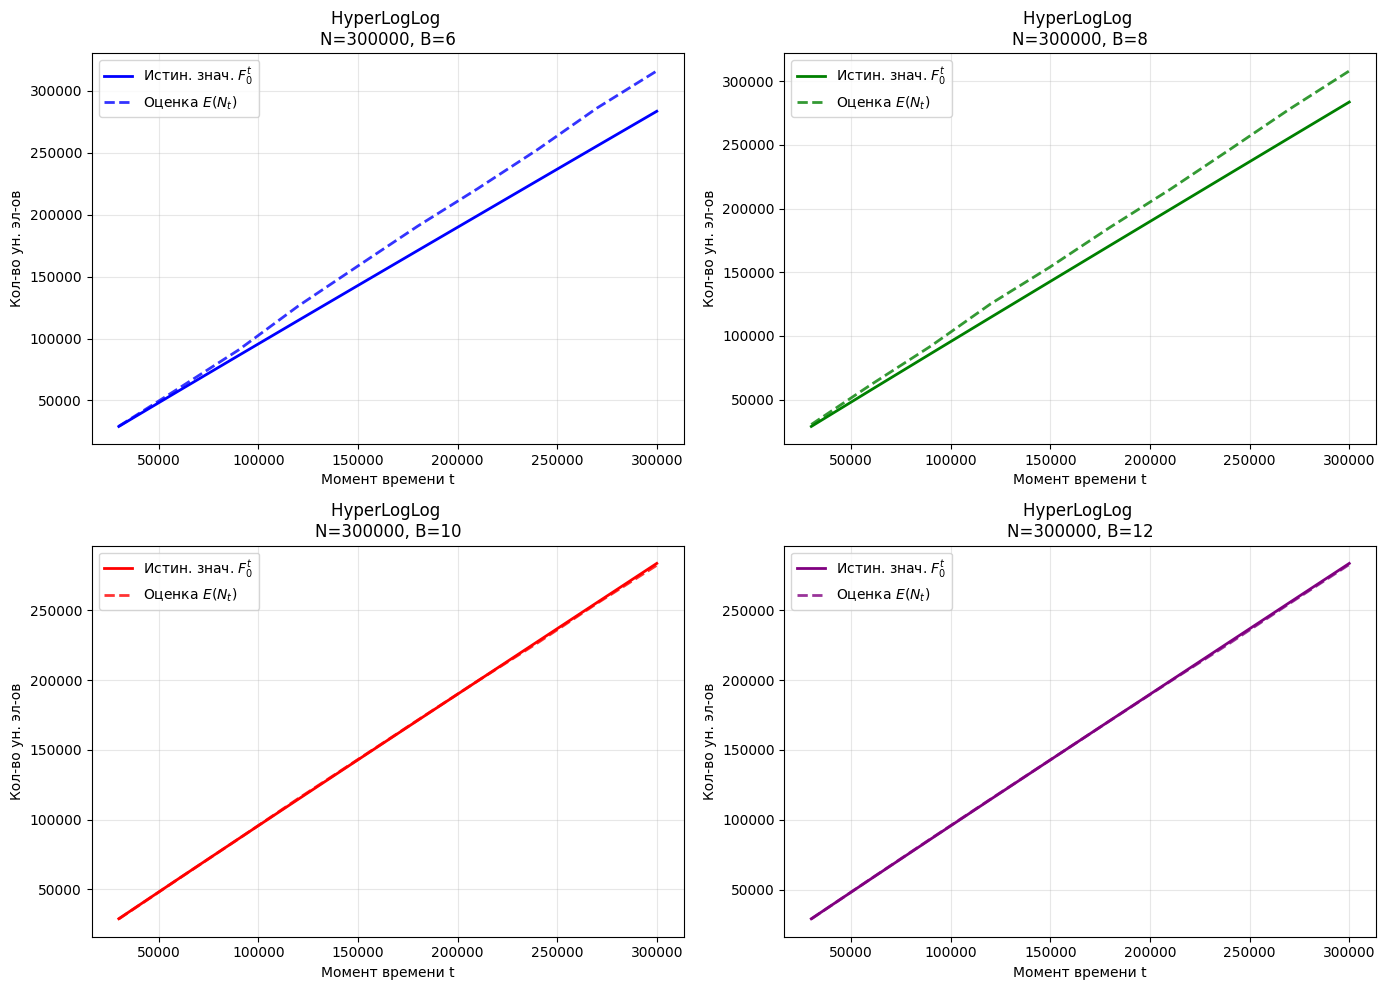

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("hll_results.csv")

STREAM_SIZE = 300000
B_VALUES = [6, 8, 10, 12]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['blue', 'green', 'red', 'purple']
line_styles = ['-', '--', '-.', ':']

for idx, B_VALUE in enumerate(B_VALUES):
    subset = df[
        (df["stream_size"] == STREAM_SIZE) &
        (df["B"] == B_VALUE)
    ].sort_values("step")

    if subset.empty:
        print(f"Нет данных для B={B_VALUE}")
        continue

    ax = axes[idx]

    ax.plot(
        subset["processed_size"],
        subset["exact"],
        label="Истин. знач. $F_0^t$",
        linewidth=2,
        color=colors[idx],
        linestyle=line_styles[0]
    )

    ax.plot(
        subset["processed_size"],
        subset["mean_estimate"],
        label="Оценка $E(N_t)$",
        linewidth=2,
        color=colors[idx],
        linestyle=line_styles[1],
        alpha=0.8
    )

    if "std_estimate" in subset.columns and "mean_estimate" in subset.columns:
        ax.fill_between(
            subset["processed_size"],
            subset["mean_estimate"] - subset["std_estimate"],
            subset["mean_estimate"] + subset["std_estimate"],
            alpha=0.2,
            color=colors[idx],
            label="±σ (std dev)"
        )

    ax.set_xlabel("Момент времени t")
    ax.set_ylabel("Кол-во ун. эл-ов")
    ax.set_title(f"HyperLogLog \nN={STREAM_SIZE}, B={B_VALUE}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    if "relative_error" in subset.columns:
        avg_error = subset["relative_error"].mean() * 100
        ax.text(0.05, 0.95, f"Avg error: {avg_error:.2f}%",
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

plt.show()


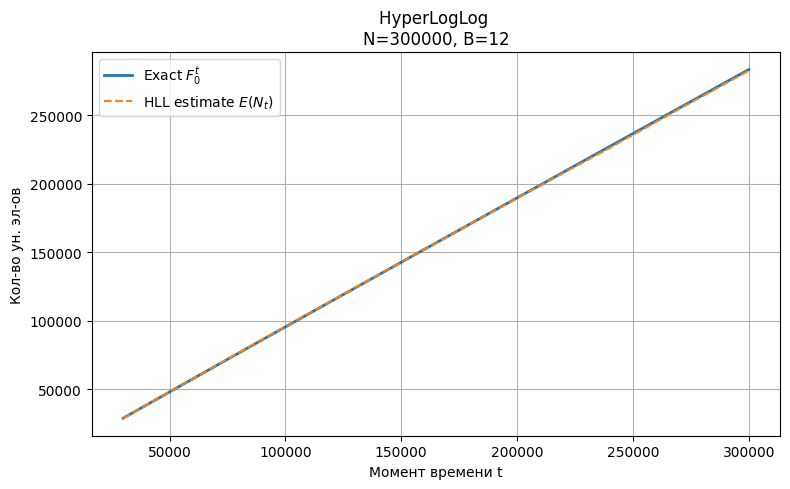

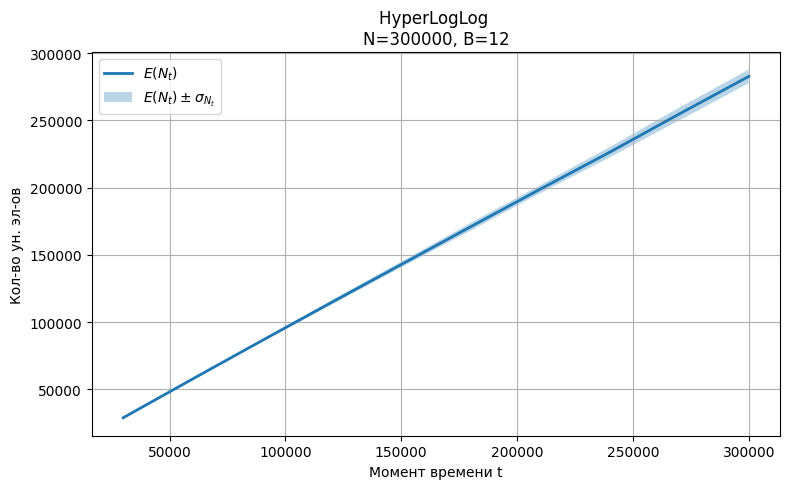

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hll_results.csv")

STREAM_SIZE = 300000
B_VALUE = 12

subset = df[
    (df["stream_size"] == STREAM_SIZE) &
    (df["B"] == B_VALUE)
].sort_values("step")

# График №1
plt.figure(figsize=(8, 5))

plt.plot(
    subset["processed_size"],
    subset["exact"],
    label="Exact $F_0^t$",
    linewidth=2
)

plt.plot(
    subset["processed_size"],
    subset["mean_estimate"],
    label="HLL estimate $E(N_t)$",
    linestyle="--"
)

plt.xlabel("Момент времени t")
plt.ylabel("Кол-во ун. эл-ов")
plt.title(f"HyperLogLog \nN={STREAM_SIZE}, B={B_VALUE}")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# График №2
plt.figure(figsize=(8, 5))

mean = subset["mean_estimate"]
std = subset["stddev"]
x = subset["processed_size"]

plt.plot(
    x,
    mean,
    label="$E(N_t)$",
    linewidth=2
)

plt.fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.3,
    label="$E(N_t) \\pm \\sigma_{N_t}$"
)

plt.xlabel("Момент времени t")
plt.ylabel("Кол-во ун. эл-ов")
plt.title(f"HyperLogLog \nN={STREAM_SIZE}, B={B_VALUE}")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()